# Height and Earnings Analysis

Does being taller make you earn more? This notebook explores that question using survey data, building a series of OLS regression models of increasing complexity.

**Key questions we will answer:**
1. Is there a raw correlation between height and earnings?
2. Does the relationship survive after controlling for gender?
3. How much does education level explain?
4. Can we predict an individual's earnings from their characteristics?


## 1. Import Libraries

In [2]:
import pandas as pd                          # data manipulation -- the workhorse library
import numpy as np                             # numerical operations (sqrt, arrays, etc.)
import seaborn as sns                          # statistical visualisations
import matplotlib.pyplot as plt               # base plotting library
from scipy import stats                        # statistical functions: t-tests, probplot
import statsmodels.formula.api as smf          # R-style formula API: smf.ols('y ~ x')
import statsmodels.api as sm                   # lower-level statsmodels API
from statsmodels.iolib.summary2 import summary_col  # side-by-side model comparison table
import warnings
warnings.filterwarnings('ignore')              # suppress noisy deprecation warnings

# --- Global display settings ---
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 decimal places in all tables
sns.set_theme(style='whitegrid')               # clean white background with grid
plt.rcParams['figure.figsize'] = (10, 6)       # default plot size for all figures

## 2. Helper Functions

We define two reusable helpers here and call them throughout the notebook.

### `fit_and_plot`
Fits an OLS model and produces a **3-panel diagnostic plot**:
- **Top**: actual vs predicted values (shows how well the model fits)
- **Bottom-left**: residuals vs fitted (checks for patterns the model missed)
- **Bottom-right**: Q-Q plot (checks whether residuals follow a normal distribution)

### `two_sample_ttest_summary`
Runs a **Welch two-sample t-test** and prints a full R-style summary with means, SDs, difference, 95% CI, t-statistic, degrees of freedom, and significance stars.

In [2]:
def fit_and_plot(formula, data, model_name="Model", x_var=None):
    """
    Fit an OLS model and produce a 3-panel diagnostic plot.
    Returns the fitted model so you can inspect it further.
    """
    # smf.ols() defines the model using an R-style formula string like 'earn ~ height'
    # .fit() runs the OLS calculation to find the best-fit coefficients
    model = smf.ols(formula=formula, data=data).fit()
    print(model.summary())  # print the full regression output table

    # If the user didn't specify which variable to put on the x-axis,
    # we automatically infer it from the formula (takes the first predictor after ~)
    if x_var is None:
        x_var = formula.split('~')[1].strip().split('+')[0].strip()

    y_var     = formula.split('~')[0].strip()   # outcome variable (left of ~)
    residuals = model.resid                      # residuals = actual - predicted

    # IMPORTANT: statsmodels silently drops rows that have missing (NaN) values.
    # We filter 'data' to only the rows the model actually used, so our plot
    # arrays are always the same length as model.fittedvalues.
    model_data = data.loc[model.fittedvalues.index]

    # Check whether the x variable is categorical (text) or numeric
    # This determines which type of plot we make in the top panel
    is_cat = model_data[x_var].dtype == object or str(model_data[x_var].dtype) == 'category'

    # Create a 2x2 grid of subplots where the top row spans both columns
    fig = plt.figure(figsize=(15, 10))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1.6, 1], hspace=0.35, wspace=0.3)
    ax_main = fig.add_subplot(gs[0, :])   # top panel: spans full width
    ax_res  = fig.add_subplot(gs[1, 0])   # bottom-left panel
    ax_qq   = fig.add_subplot(gs[1, 1])   # bottom-right panel

    # --- Panel 1: Actual vs Predicted ---
    if is_cat:
        # For a categorical x: show individual data points jittered (stripplot)
        # plus a horizontal line at the predicted group mean
        sns.stripplot(x=model_data[x_var], y=model_data[y_var],
                      alpha=0.3, color='black', s=4, ax=ax_main, label='Actual')
        group_means = model_data.groupby(x_var)[y_var].mean()
        ax_main.hlines(group_means.values,
                       xmin=[i - 0.3 for i in range(len(group_means))],
                       xmax=[i + 0.3 for i in range(len(group_means))],
                       colors='red', linewidth=2, label='Predicted mean')
    else:
        # For a continuous x: scatter plot of actual (black) vs predicted (red)
        # .values strips the pandas index so matplotlib doesn't get confused
        ax_main.scatter(model_data[x_var].values, model_data[y_var].values,
                        alpha=0.3, color='black', s=15, label='Actual')
        ax_main.scatter(model_data[x_var].values, model.fittedvalues.values,
                        alpha=0.3, color='red', s=15, label='Predicted')

    ax_main.set_title(f'Actual vs Predicted -- x: {x_var}', fontsize=13)
    ax_main.set_xlabel(x_var)
    ax_main.set_ylabel(y_var)
    ax_main.legend()

    # --- Panel 2: Residuals vs Fitted ---
    # A good model has residuals scattered randomly around 0 (the dashed red line).
    # A fan shape means the model's errors grow with the prediction (heteroscedasticity).
    ax_res.scatter(model.fittedvalues, residuals, alpha=0.3, color='steelblue', s=15)
    ax_res.axhline(0, color='red', linewidth=1, linestyle='--')  # zero reference line
    ax_res.set_title('Residuals vs Fitted', fontsize=11)
    ax_res.set_xlabel('Fitted Values')
    ax_res.set_ylabel('Residuals')

    # --- Panel 3: Q-Q Plot (Quantile-Quantile) ---
    # If the residuals are normally distributed, they should fall close to the
    # diagonal red line. Deviations indicate non-normality (e.g. heavy tails).
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    ax_qq.scatter(osm, osr, alpha=0.3, color='steelblue', s=15)
    ax_qq.plot(osm, slope * np.array(osm) + intercept,
               color='red', linewidth=1, linestyle='--')
    ax_qq.set_title('Q-Q Plot of Residuals', fontsize=11)
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Sample Quantiles')

    # Suptitle shows the model name and two goodness-of-fit metrics
    plt.suptitle(f'{model_name}  |  R2 = {model.rsquared:.3f}  |  Adj R2 = {model.rsquared_adj:.3f}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    return model  # return the model so we can store it and compare it later


def two_sample_ttest_summary(a, b, col, label_a, label_b):
    """
    Welch two-sample t-test with R-style output.
    Welch's test does NOT assume equal variances between groups -- safer default.
    Prints: n, mean, std, difference, 95% CI, t-statistic, df, p-value + stars.
    """
    x, y = a[col].dropna(), b[col].dropna()   # drop any missing values first

    # ttest_ind with equal_var=False runs Welch's test
    t, p = stats.ttest_ind(x, y, equal_var=False)

    # Calculate the Welch-Satterthwaite degrees of freedom (more conservative than n1+n2-2)
    df_w = (x.var()/len(x) + y.var()/len(y))**2 / (
            (x.var()/len(x))**2/(len(x)-1) + (y.var()/len(y))**2/(len(y)-1))

    diff = x.mean() - y.mean()                          # observed difference in means
    se   = np.sqrt(x.var()/len(x) + y.var()/len(y))    # standard error of the difference
    ci   = stats.t.interval(0.95, df=df_w, loc=diff, scale=se)  # 95% confidence interval

    # Significance stars: *** very strong, ** strong, * moderate, ns = not significant
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

    print(f"--- Welch Two-Sample T-Test: {col} | {label_a} vs {label_b} ---")
    print(f"  n         : {len(x)}  vs  {len(y)}")
    print(f"  mean      : {x.mean():,.4f}  vs  {y.mean():,.4f}")
    print(f"  std       : {x.std(ddof=1):,.4f}  vs  {y.std(ddof=1):,.4f}")
    print(f"  diff      : {diff:,.4f}  ({label_a} minus {label_b})")
    print(f"  95% CI    : [{ci[0]:,.4f}, {ci[1]:,.4f}]")
    print(f"  t         : {t:.4f}")
    print(f"  df        : {df_w:.2f}")
    print(f"  p-value   : {p:.6f}  {sig}")

print("Helper functions defined.")

Helper functions defined.


## 3. Load & Inspect Data

In [3]:
# Read the CSV into a pandas DataFrame
height_earnings = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/data_analytics_executives/main/data/height_earnings.csv")

# .shape returns (rows, columns) -- a quick sanity check
print('Shape:', height_earnings.shape)

# .dtypes shows what type of data is in each column (int, float, str, etc.)
print('\nColumn types:')
print(height_earnings.dtypes)

# .describe() computes summary statistics for all numeric columns
# .T transposes (flips rows/columns) so it's easier to read
print('\nSummary statistics:')
height_earnings.describe().T

Shape: (1376, 7)

Column types:
earn          int64
height      float64
age           int64
ed_level        str
race            str
hispanic      int64
gender          str
dtype: object

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
earn,1376.0000,19985.0945,19767.5597,0.0000,6000.0000,16020.0000,28000.0000,200000.0000
height,1376.0000,169.1426,9.6640,147.3200,162.5600,167.6400,175.2600,195.5800
age,1376.0000,41.2202,15.6354,18.0000,29.0000,38.0000,51.0000,89.0000
hispanic,1376.0000,0.0523,0.2228,0.0000,0.0000,0.0000,0.0000,1.0000


## 4. Prepare Data — Order Education Levels

Education level is an **ordered categorical** variable: Elementary < High School < College < Some Graduate School < Graduate Diploma.

In Python we use `pd.Categorical` with `ordered=True` to encode this ordering. This matters because:
- Plots will display levels in the correct order (not alphabetically)
- Some models can treat the ordering meaningfully

In [4]:
# Define the correct ordering from least to most advanced education
ed_order = ['Elementary', 'High School', 'College', 'Some Graduate School', 'Graduate Diploma']

height_earnings = (
    height_earnings
    .assign(
        # pd.Categorical with ordered=True tells pandas this column has a meaningful ranking
        # Without this, pandas treats education level as unordered text
        ed_level=lambda df: pd.Categorical(
            df['ed_level'],
            categories=ed_order,
            ordered=True
        )
    )
)

print('Education levels in order:')
print(height_earnings['ed_level'].cat.categories.tolist())

Education levels in order:
['Elementary', 'High School', 'College', 'Some Graduate School', 'Graduate Diploma']


## 5. Exploratory Analysis

### 5a. Overall earnings summary

Before building any model, we look at the raw distribution of earnings. Key things to notice: the mean is much higher than the median (right-skewed distribution), and the max is very high (200k) -- earnings distributions almost always look like this.

In [5]:
# .describe() gives us count, mean, std, min, quartiles, max
print('Overall earnings summary:')
print(height_earnings['earn'].describe())

print('\nEarnings summary by gender:')
# .groupby() splits the data by gender, then we compute stats for each group
# .assign() adds a standard error column: SE = SD / sqrt(n)
(
    height_earnings
    .groupby('gender')['earn']
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .assign(se=lambda df: df['std'] / np.sqrt(df['count']))  # SE tells us how uncertain the mean is
    .round(2)
)

Overall earnings summary:
count     1376.0000
mean     19985.0945
std      19767.5597
min          0.0000
25%       6000.0000
50%      16020.0000
75%      28000.0000
max     200000.0000
Name: earn, dtype: float64

Earnings summary by gender:


,count,mean,std,min,median,max,se
gender,,,,,,,
Female,857,14567.6700,14666.1000,0,12000.0000,123000,500.9800
Male,519,28930.6300,23517.2600,0,25000.0000,200000,1032.2900


### 5b. Earnings by gender AND education level

Breaking down by both gender and education simultaneously reveals the interaction: men with Graduate Diplomas earn on average \$60k vs \$29k for women with the same qualification -- a dramatic gap.

In [6]:
# groupby with a LIST of columns creates a multi-level breakdown
# observed=True is needed when one of the columns is a Categorical to avoid empty groups
(
    height_earnings
    .groupby(['gender', 'ed_level'], observed=True)['earn']
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .assign(se=lambda df: df['std'] / np.sqrt(df['count']))  # standard error
    .round(2)
)

count       mean        std   min     median  \
gender ed_level                                                             
Female Elementary               29  4617.3800  5514.3600     0  2400.0000   
       High School             396 10438.6900 10859.2600     0  9500.0000   
       College                 350 17258.2000 15924.2100     0 15000.0000   
       Some Graduate School     40 23587.5000 13047.6900     0 24500.0000   
       Graduate Diploma         42 29357.1400 20334.7900     0 26500.0000   
Male   Elementary               17 13360.2400 11450.5100     0 12000.0000   
       High School             221 23128.2400 15429.4500     0 21000.0000   
       College                 213 29856.9500 21035.2800     0 26000.0000   
       Some Graduate School     30 34133.3300 23200.3800  3000 29000.0000   
       Graduate Diploma         38 60342.1100 44279.9900  1000 46000.0000   

                                max        se  
gender ed_level                                
Female Elementary             20000 1023.9900  
       High School            70000  545.7000  
       College               123000  851.1800  
       Some Graduate School   53000 2063.0200  
       Graduate Diploma      110000 3137.7300  
Male   Elementary             50000 2777.1600  
       High School           105000 1037.9000  
       College               175000 1441.3100  
       Some Graduate School  100000 4235.7900  
       Graduate Diploma      200000 7183.1600

### 5c. T-test: Do men and women earn differently?

We use `two_sample_ttest_summary` to test whether the mean earnings gap between men and women is statistically significant, or could just be due to random sampling variation.

**Null hypothesis (H0)**: mean earnings are the same for men and women  
**Alternative (H1)**: they differ

In [7]:
# Split the data into two groups: male and female earners
male_earn   = height_earnings.loc[height_earnings['gender'] == 'Male']
female_earn = height_earnings.loc[height_earnings['gender'] == 'Female']

# Run the Welch t-test and print R-style output
two_sample_ttest_summary(male_earn, female_earn, col='earn',
                         label_a='Male', label_b='Female')

--- Welch Two-Sample T-Test: earn | Male vs Female ---
  n         : 519  vs  857
  mean      : 28,930.6281  vs  14,567.6709
  std       : 23,517.2598  vs  14,666.0987
  diff      : 14,362.9572  (Male minus Female)
  95% CI    : [12,110.4561, 16,615.4582]
  t         : 12.5174
  df        : 765.06
  p-value   : 0.000000  ***


### 5d. Heatmap- correlation matrix



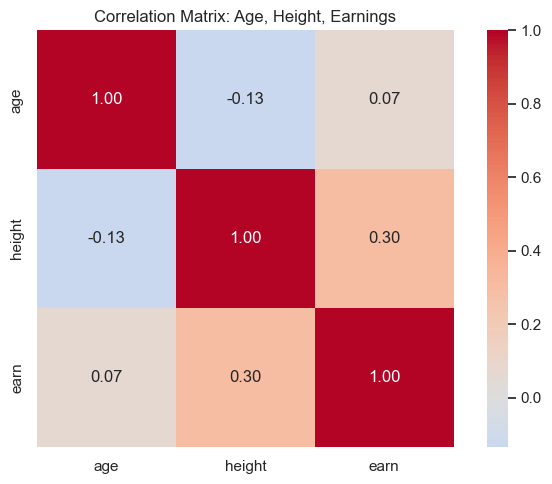

In [8]:


numeric_cols = height_earnings[['age', 'height', 'earn']].select_dtypes(include=['number']).columns
corr_matrix = height_earnings[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            square=True, 
            fmt='.2f')
plt.title('Correlation Matrix: Age, Height, Earnings')
plt.tight_layout()
plt.show()


## 6. Model Building

We build five models of increasing complexity. Each call to `fit_and_plot` automatically:
1. Fits the OLS model
2. Prints the full regression summary
3. Produces the 3-panel diagnostic plot

| Model | Formula | Key question |
|---|---|---|
| M0 | `earn ~ 1` | Baseline: just predict the mean |
| M1 | `earn ~ height` | Does height predict earnings? |
| M2 | `earn ~ height + gender` | Does the height effect survive after controlling for gender? |
| M3 | `earn ~ .` (all variables) | Kitchen sink: what happens with everything included? |
| M4 | `earn ~ . - race - hispanic` | Remove non-significant variables |

### Model 0 — Intercept Only (Baseline)

Predicts the same value (the overall mean) for everyone. R-squared = 0 by definition. This is our baseline -- any useful predictor should beat it.

In [9]:
# Intercept-only model: 'earn ~ 1' means predict a constant (the sample mean)
# This is the baseline -- it tells us how bad our predictions are with no information at all
model0 = smf.ols('earn ~ 1', data=height_earnings).fit()
print(model0.summary())

                            OLS Regression Results                            
Dep. Variable:                   earn   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 20 Mar 2026   Prob (F-statistic):                nan
Time:                        21:07:53   Log-Likelihood:                -15563.
No. Observations:                1376   AIC:                         3.113e+04
Df Residuals:                    1375   BIC:                         3.113e+04
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.999e+04    532.898     37.503      0.0

### Model 1 — Height Only

Our first substantive question: does being taller lead to higher earnings?

                            OLS Regression Results                            
Dep. Variable:                   earn   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     138.3
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.73e-30
Time:                        21:08:02   Log-Likelihood:                -15497.
No. Observations:                1376   AIC:                         3.100e+04
Df Residuals:                    1374   BIC:                         3.101e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8.463e+04   8911.271     -9.497      0.0

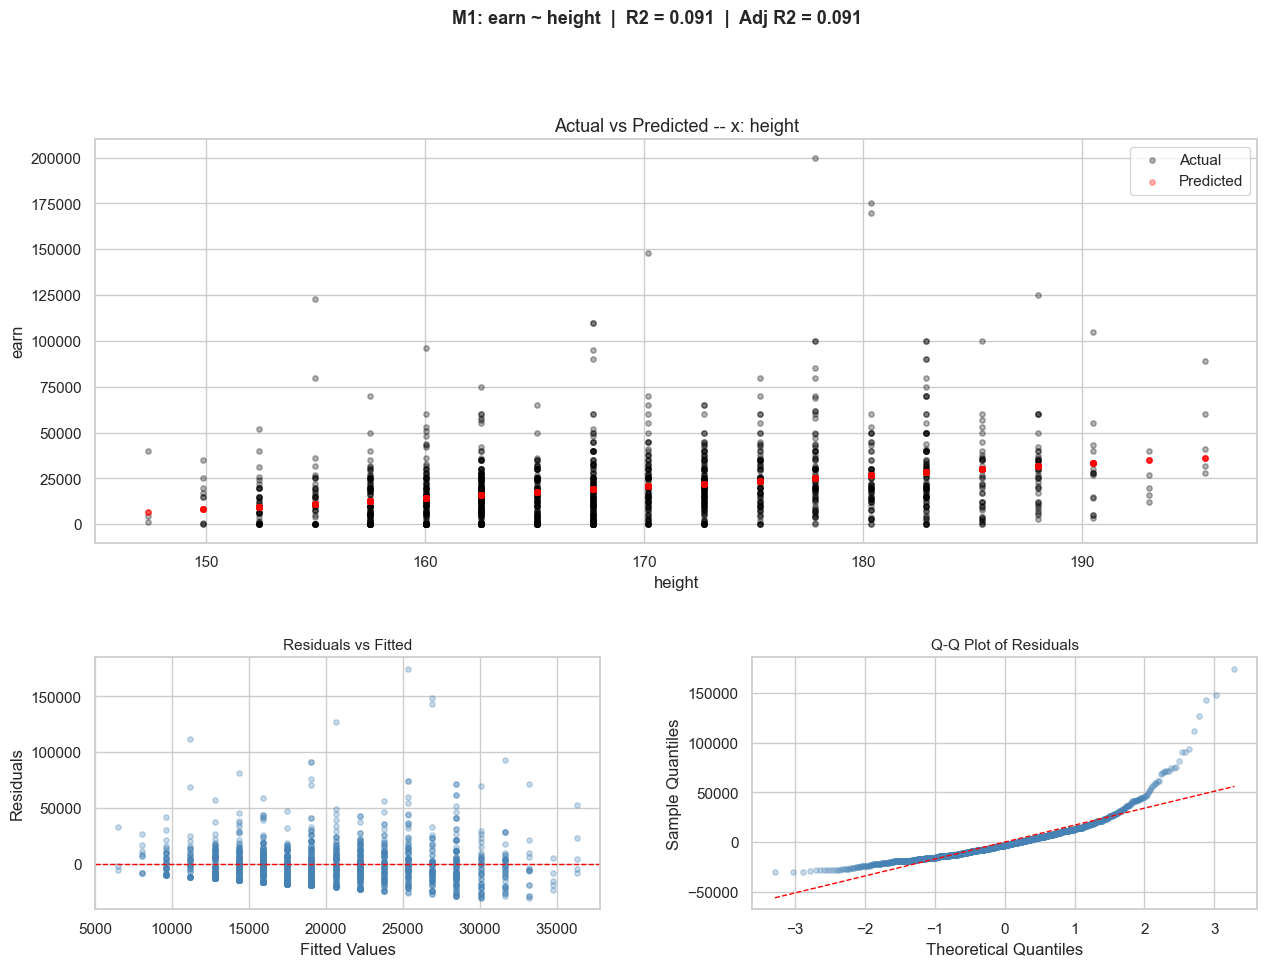

In [10]:
# height alone as the single predictor
# The coefficient on height tells us: for each 1cm increase in height,
# how many extra dollars does the model predict in annual earnings?
model1 = fit_and_plot(
    formula='earn ~ height',
    data=height_earnings,
    model_name='M1: earn ~ height',
    x_var='height'
)

### Model 2 — Height + Gender

Gender is a **confounding variable**: men are on average taller AND earn more. If we omit gender, the height coefficient is inflated -- it is picking up the gender effect. This is called **omitted variable bias**.

Adding gender lets us ask: *within each gender*, does height predict earnings?

                            OLS Regression Results                            
Dep. Variable:                   earn   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     102.5
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           3.34e-42
Time:                        21:08:11   Log-Likelihood:                -15467.
No. Observations:                1376   AIC:                         3.094e+04
Df Residuals:                    1373   BIC:                         3.096e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -2.133e+04   1.19e+04     -1.

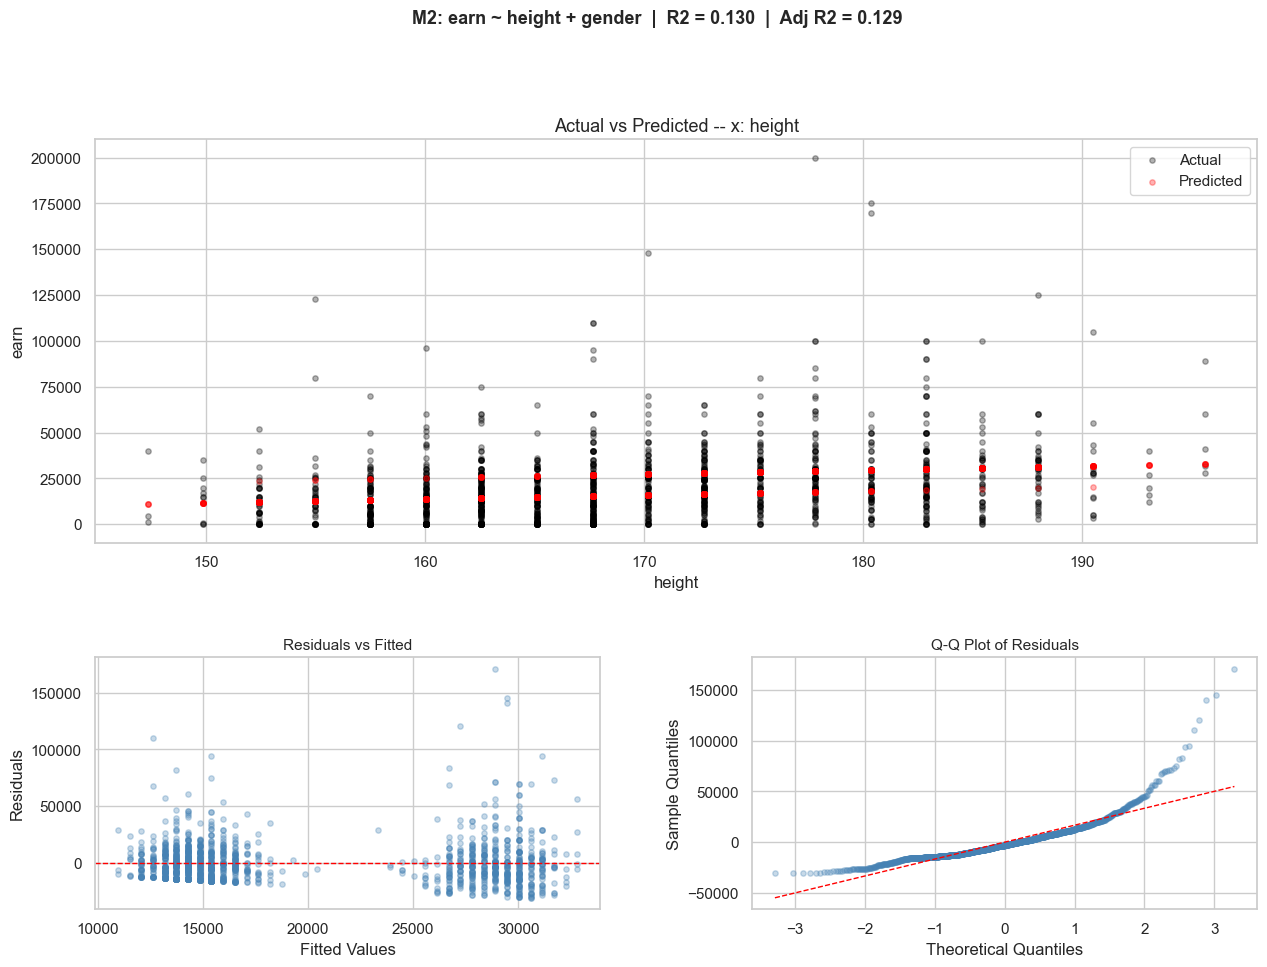

In [11]:
# Adding gender controls for the fact that men are both taller and higher-earning on average
# gender[T.Male] is the dummy variable coefficient: how much more do men earn vs women
# after holding height constant?
model2 = fit_and_plot(
    formula='earn ~ height + gender',
    data=height_earnings,
    model_name='M2: earn ~ height + gender',
    x_var='height'
)

### Model 3 — All Variables (Kitchen Sink)

We include every available predictor. We build the formula string dynamically so we don't have to type it out, and we wrap categorical columns in `C()` so statsmodels knows to create dummy variables.

Formula: earn ~ height + age + C(ed_level) + race + hispanic + gender
                            OLS Regression Results                            
Dep. Variable:                   earn   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.262
Method:                 Least Squares   F-statistic:                     41.62
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           6.88e-84
Time:                        21:08:26   Log-Likelihood:                -15348.
No. Observations:                1376   AIC:                         3.072e+04
Df Residuals:                    1363   BIC:                         3.079e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

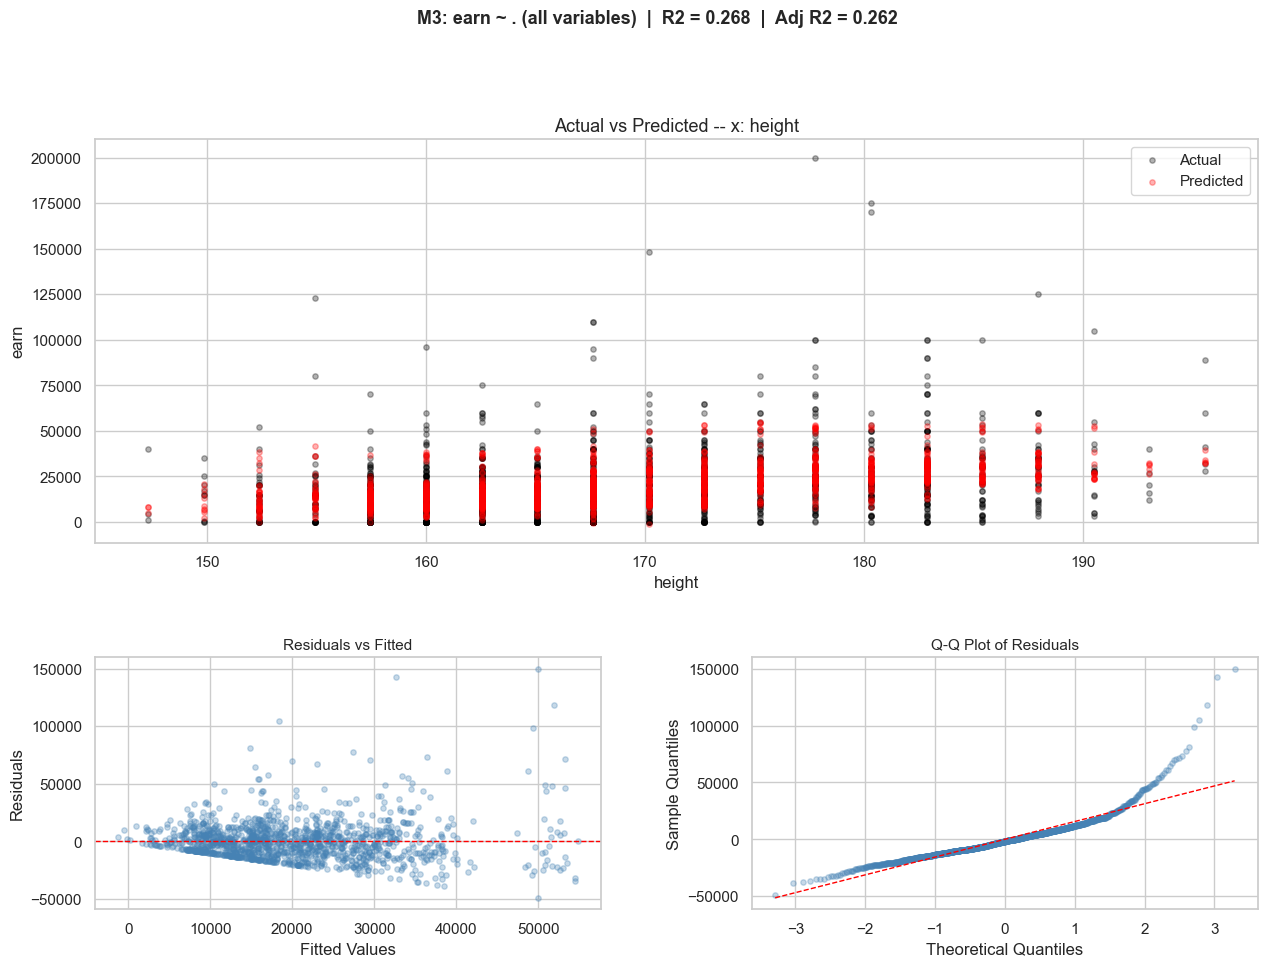

In [12]:
# Build the list of predictors: everything except 'earn' (our outcome variable)
predictors = [c for c in height_earnings.columns if c != 'earn']

# For each predictor, check if it's categorical (object or Categorical dtype)
# Categorical predictors need to be wrapped in C() so statsmodels creates dummies
formula3 = 'earn ~ ' + ' + '.join([
    f'C({c})' if height_earnings[c].dtype == 'object' or str(height_earnings[c].dtype) == 'category'
    else c
    for c in predictors
])
print('Formula:', formula3)

# Fit and plot -- x_var='height' so we can see the height effect visually
model3 = fit_and_plot(
    formula=formula3,
    data=height_earnings,
    model_name='M3: earn ~ . (all variables)',
    x_var='height'
)

### Model 4 — Drop Race and Hispanic

After inspecting Model 3, we remove `race` and `hispanic` because their coefficients are not statistically significant (p > 0.05), meaning we cannot distinguish their effect from zero. Removing them keeps the model simpler and avoids overfitting.

Formula: earn ~ height + age + C(ed_level) + gender
                            OLS Regression Results                            
Dep. Variable:                   earn   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.262
Method:                 Least Squares   F-statistic:                     70.59
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           3.38e-87
Time:                        21:11:28   Log-Likelihood:                -15351.
No. Observations:                1376   AIC:                         3.072e+04
Df Residuals:                    1368   BIC:                         3.076e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

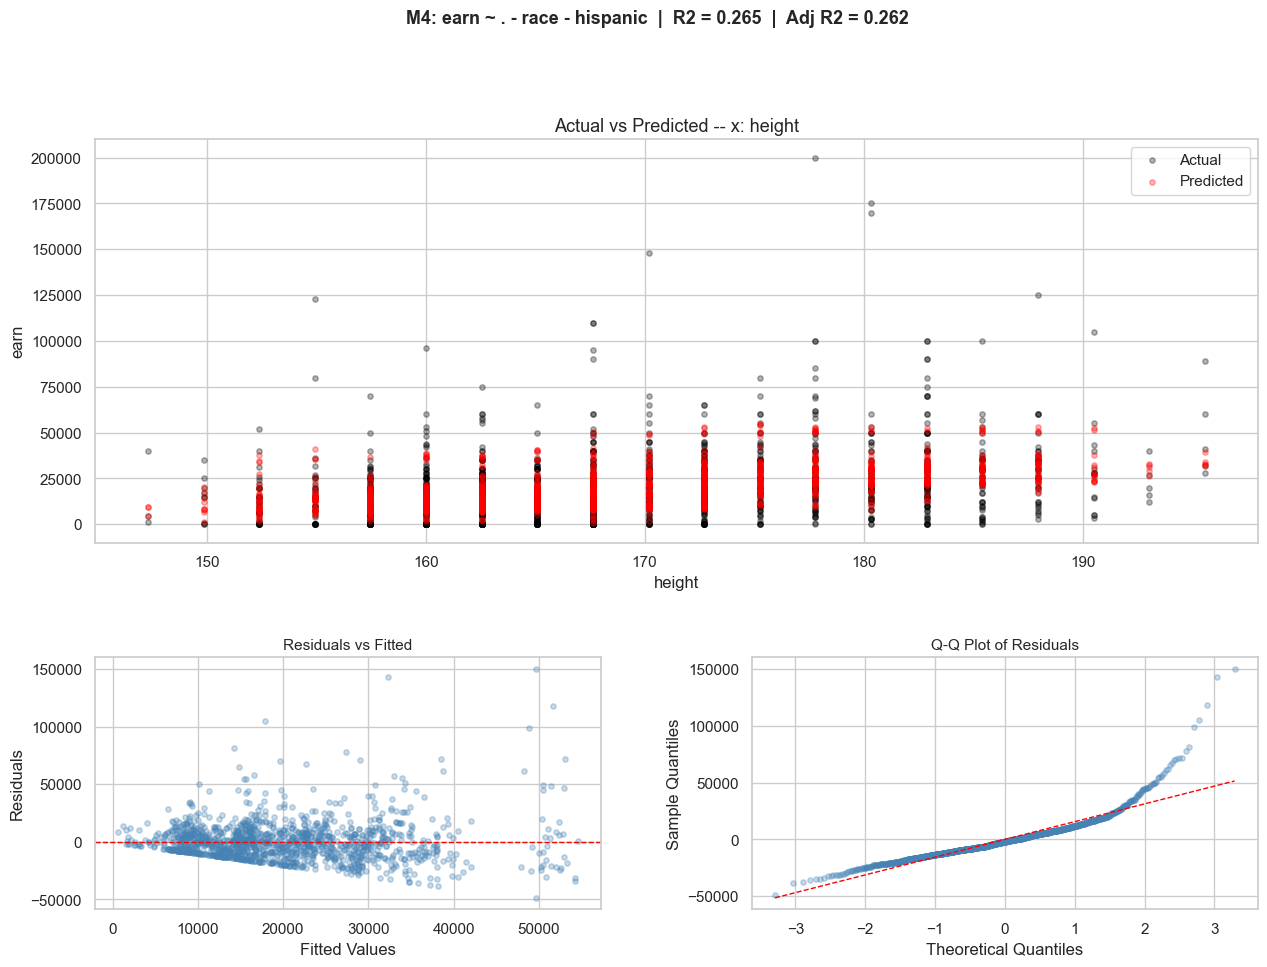

In [13]:
# Remove race and hispanic from the predictor list (not statistically significant in M3)
predictors4 = [c for c in predictors if c not in ['race', 'hispanic']]

formula4 = 'earn ~ ' + ' + '.join([
    f'C({c})' if height_earnings[c].dtype == 'object' or str(height_earnings[c].dtype) == 'category'
    else c
    for c in predictors4
])
print('Formula:', formula4)

model4 = fit_and_plot(
    formula=formula4,
    data=height_earnings,
    model_name='M4: earn ~ . - race - hispanic',
    x_var='height'
)

## 7. Model Comparison

We compare all five models side by side. Key metrics to look at:
- **R-squared**: proportion of earnings variance explained (higher = better fit)
- **Adj. R-squared**: R-squared penalised for adding extra predictors (fairer comparison across models with different numbers of variables)
- **Residual SE**: average prediction error in dollars (lower = better)
- **AIC / BIC**: penalised fit metrics -- lower is better, useful for selecting between models

In [14]:
# Collect all models into a dictionary with readable names
models = {
    'M0: ~1':           model0,
    'M1: ~height':      model1,
    'M2: ~height+gender': model2,
    'M3: ~all':         model3,
    'M4: ~all-race-hisp': model4,
}

# Build a comparison DataFrame: one column per model, one row per metric
comparison = pd.DataFrame({
    name: {
        'N':           int(m.nobs),               # number of observations used
        'R2':          round(m.rsquared, 4),      # variance explained
        'Adj. R2':     round(m.rsquared_adj, 4),  # variance explained, penalised for predictors
        'Residual SE': round(np.sqrt(m.mse_resid), 2),  # average prediction error ($)
        'AIC':         round(m.aic, 1),            # lower = better fit/complexity trade-off
        'BIC':         round(m.bic, 1),            # like AIC but penalises complexity more heavily
    }
    for name, m in models.items()
})

display(comparison)

,M0: ~1,M1: ~height,M2: ~height+gender,M3: ~all,M4: ~all-race-hisp
N,1376.0000,1376.0000,1376.0000,1376.0000,1376.0000
R2,0.0000,0.0914,0.1299,0.2682,0.2654
Adj. R2,0.0000,0.0908,0.1286,0.2617,0.2616
Residual SE,19767.5600,18849.0100,18452.7300,16984.6500,16986.3200
AIC,31128.1000,30998.2000,30940.7000,30722.5000,30717.8000
BIC,31133.4000,31008.7000,30956.4000,30790.5000,30759.6000


## 8. Predictions — Imaginary Person

We use Model 4 to predict earnings for a specific hypothetical person: a 40-year-old white male with a Graduate Diploma, at heights ranging from 175 to 185 cm.

The **prediction interval** (shaded band) is wider than a confidence interval -- it captures the uncertainty for an *individual* person, not just the average.

In [15]:
# Create a small DataFrame describing our imaginary person at 11 different heights
imaginary_man = pd.DataFrame({
    'height':   range(175, 186),        # heights 175, 176, ... 185 cm
    'gender':   'Male',                 # constant across all rows
    'age':      40,
    'race':     'white',
    'hispanic': 0,                      # not hispanic (0 = no, 1 = yes)
    'ed_level': 'Graduate Diploma'
})

# We must assign the same ordered Categorical dtype as in the training data
# Otherwise statsmodels won't recognise the ed_level column correctly
imaginary_man['ed_level'] = pd.Categorical(
    imaginary_man['ed_level'], categories=ed_order, ordered=True
)

# get_prediction() returns fitted values + standard errors + confidence intervals
# summary_frame(alpha=0.05) gives us the 95% intervals as a neat DataFrame
predictions = model4.get_prediction(imaginary_man)
pred_df     = predictions.summary_frame(alpha=0.05)

# Combine the input heights with the predicted earnings and intervals
result = (
    imaginary_man[['height']]
    .assign(
        predicted_earn = pred_df['mean'].values,         # the model's point estimate
        lower_95_pi    = pred_df['obs_ci_lower'].values, # lower bound of prediction interval
        upper_95_pi    = pred_df['obs_ci_upper'].values  # upper bound of prediction interval
    )
    .round(0)  # round to nearest dollar
)

print('Predicted earnings for a 40-yr-old male Graduate Diploma holder:')
display(result)

Predicted earnings for a 40-yr-old male Graduate Diploma holder:


,height,predicted_earn,lower_95_pi,upper_95_pi
0,175,49984.0000,16435.0000,83532.0000
1,176,50161.0000,16615.0000,83708.0000
2,177,50339.0000,16794.0000,83885.0000
3,178,50517.0000,16972.0000,84062.0000
4,179,50695.0000,17150.0000,84240.0000
5,180,50873.0000,17328.0000,84418.0000
6,181,51051.0000,17504.0000,84597.0000
7,182,51228.0000,17681.0000,84776.0000
8,183,51406.0000,17857.0000,84956.0000
9,184,51584.0000,18032.0000,85136.0000


## 9. Plot Predicted Earnings vs Height

The shaded band is the 95% **prediction interval** -- for any individual with these characteristics, we expect their actual earnings to fall in this range 95% of the time. Notice how wide it is: individual earnings are very hard to predict precisely even with a good model.

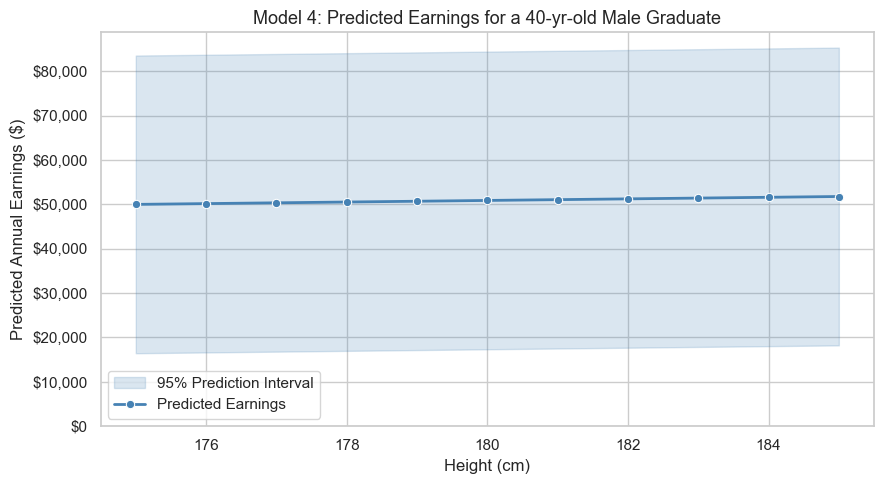

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

# Ribbon: matplotlib's fill_between -- seaborn has no equivalent for this
ax.fill_between(
    result['height'],
    result['lower_95_pi'],
    result['upper_95_pi'],
    alpha=0.2, color='steelblue', label='95% Prediction Interval'
)

# Line + points: seaborn lineplot
sns.lineplot(
    data=result, x='height', y='predicted_earn',
    marker='o', color='steelblue', linewidth=2, label='Predicted Earnings', ax=ax
)

ax.set_ylim(bottom=0)   # y-axis starts at zero
ax.set_xlabel('Height (cm)', fontsize=12)
ax.set_ylabel('Predicted Annual Earnings ($)', fontsize=12)
ax.set_title('Model 4: Predicted Earnings for a 40-yr-old Male Graduate', fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()